# Day 8: Prophet + LSTM Ensemble

Combines Day 5's Prophet baseline and Day 6's LSTM into a single forecast.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.forecasting import load_demand_series, evaluate_forecast
from src.models.lstm_forecasting import build_feature_frame
from src.models.ensemble_forecasting import get_validation_predictions, fit_global_weight, fit_day_type_weights, apply_day_type_weights

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = load_demand_series(column="quantity")
feature_df = build_feature_frame(df)

prophet_test = pd.read_csv("../data/features/forecast_artifacts/prophet_holdout_comparison.csv")
lstm_test = pd.read_csv("../data/features/forecast_artifacts/lstm_holdout_comparison.csv")
test_df = pd.DataFrame({
    "ds": prophet_test["ds"].to_numpy(),
    "actual": prophet_test["actual"].to_numpy(),
    "prophet_pred": prophet_test["prophet_yhat"].to_numpy(),
    "lstm_pred": lstm_test["lstm_yhat"].to_numpy(),
})
test_df.tail(3)

d:\retailplus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,ds,actual,prophet_pred,lstm_pred
53,2011-12-06,30346,25501.132820,31186.377141
54,2011-12-07,41766,23060.072110,30701.996787
55,2011-12-08,34991,25414.942373,30947.496610


## sample validation predictions

Both models are retrained on `train_inner` (626 days).

In [2]:
val_results = get_validation_predictions(df, feature_df)

prophet_val_metrics = evaluate_forecast(val_results["actual"], val_results["prophet_pred"])
lstm_val_metrics = evaluate_forecast(val_results["actual"], val_results["lstm_pred"])
print(f"Validation MAPE -- Prophet: {prophet_val_metrics['mape']:.2f}%, LSTM: {lstm_val_metrics['mape']:.2f}%")

d:\retailplus\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\retailplus\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
d:\retailplus\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Validation MAPE -- Prophet: 35.45%, LSTM: 30.75%


Both models score *worse* on this validation window than they did on the
actual test window in Day 5/6 (Prophet 35.5% vs. 25.2%, LSTM 31.3% vs.
22.5%).
The validation window is trained on 56 fewer days of history than the models. 

## global weight

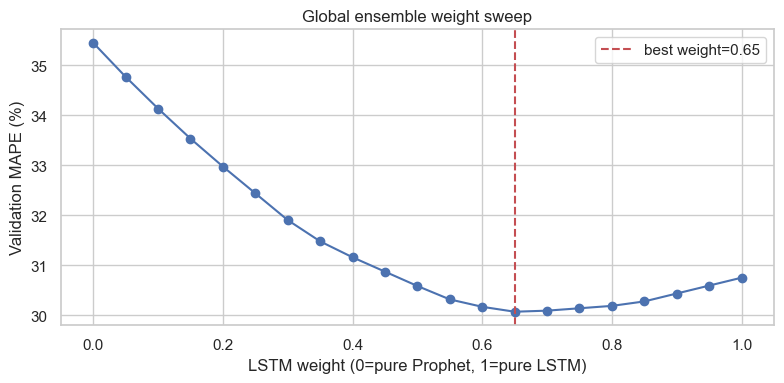

Best global weight: 0.65 (LSTM), 0.35 (Prophet)


In [3]:
best_weight, sweep = fit_global_weight(val_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep["weight"], sweep["mape"], marker="o", color="#4C72B0")
ax.axvline(best_weight, color="#C44E52", linestyle="--", label=f"best weight={best_weight:.2f}")
ax.set_xlabel("LSTM weight (0=pure Prophet, 1=pure LSTM)")
ax.set_ylabel("Validation MAPE (%)")
ax.set_title("Global ensemble weight sweep")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Best global weight: {best_weight:.2f} (LSTM), {1-best_weight:.2f} (Prophet)")

In [4]:
global_test_pred = best_weight * test_df["lstm_pred"] + (1 - best_weight) * test_df["prophet_pred"]
global_metrics = evaluate_forecast(test_df["actual"], global_test_pred)
global_metrics

{'mae': 5646.470471207963,
 'rmse': 7087.545671803636,
 'mape': 21.890432379094115,
 'n_excluded_zero_actual': 8,
 'n_total': 56}

## day-type weights

Day 5-6 already showed the two models' relative strengths differ sharply
by day type (LSTM better on Saturday/Sunday, mixed on weekdays).

In [5]:
day_type_weights = fit_day_type_weights(val_results)
day_type_weights

d:\retailplus\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\retailplus\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


{'weekday': 0.55, 'saturday': 1.0, 'sunday': 1.0}

In [6]:
day_type_test_pred = apply_day_type_weights(test_df, day_type_weights)
day_type_metrics = evaluate_forecast(test_df["actual"], day_type_test_pred)
day_type_metrics

{'mae': 5640.698740456595,
 'rmse': 7131.563184285924,
 'mape': 21.883175522791042,
 'n_excluded_zero_actual': 8,
 'n_total': 56}

## comparison

In [8]:
naive_metrics = {"mape": 24.58, "mae": 5610.0, "rmse": 7711.7}
prophet_metrics = {"mape": 25.23, "mae": 6336.0, "rmse": 7651.6}
lstm_metrics = evaluate_forecast(test_df["actual"], test_df["lstm_pred"])

comparison = pd.DataFrame({
    "seasonal_naive": naive_metrics,
    "prophet": prophet_metrics,
    "lstm": lstm_metrics,
    "ensemble_global": global_metrics,
    "ensemble_day_type": day_type_metrics,
}).T[["mape", "mae", "rmse"]]

comparison.to_csv("../data/features/forecast_artifacts/ensemble_holdout_comparison.csv", index=False)
comparison      


,mape,mae,rmse
seasonal_naive,24.580000,5610.000000,7711.700000
prophet,25.230000,6336.000000,7651.600000
lstm,22.054448,5562.988295,7013.407028
ensemble_global,21.890432,5646.470471,7087.545672
ensemble_day_type,21.883176,5640.698740,7131.563184


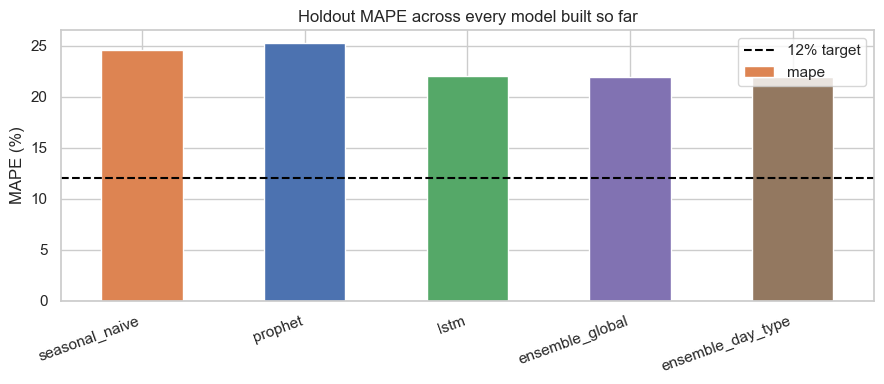

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
comparison["mape"].plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0", "#55A868", "#8172B2", "#937860"])
ax.axhline(12, color="black", linestyle="--", label="12% target")
ax.set_ylabel("MAPE (%)")
ax.set_title("Holdout MAPE across every model built so far")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Holdout: actual vs. the day-type ensemble

2026-06-29 20:48:52,941 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-29 20:48:52,944 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-29 20:48:52,947 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-29 20:48:52,949 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-29 20:48:52,954 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

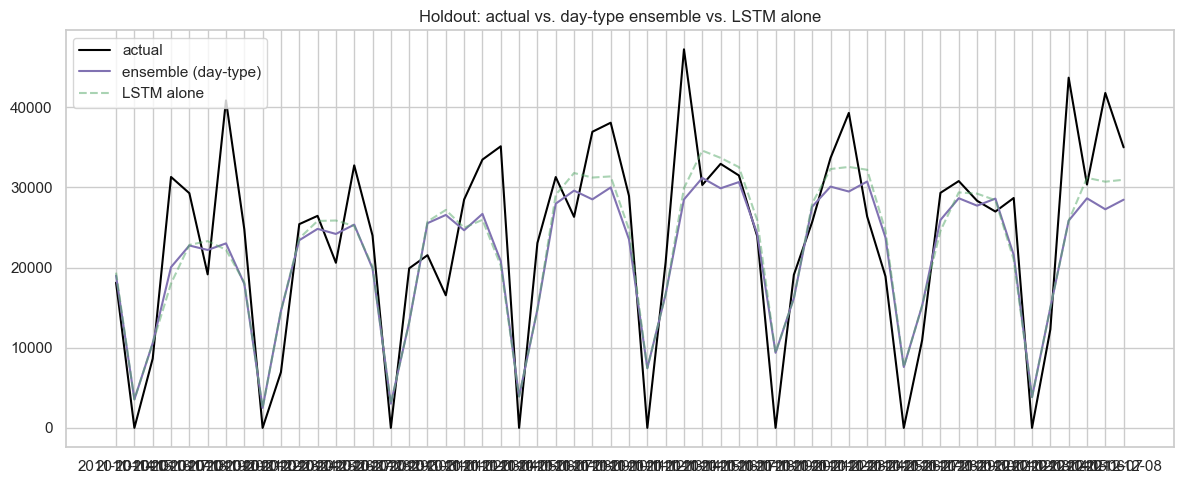

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df["ds"], test_df["actual"], label="actual", color="black", linewidth=1.5)
ax.plot(test_df["ds"], day_type_test_pred, label="ensemble (day-type)", color="#8172B2")
ax.plot(test_df["ds"], test_df["lstm_pred"], label="LSTM alone", color="#55A868", alpha=0.5, linestyle="--")
ax.set_title("Holdout: actual vs. day-type ensemble vs. LSTM alone")
ax.legend()
plt.tight_layout()
plt.show()

## Day 8 findings summary

- Ensemble weights were selected on a 56-day validation window
- Global weight (0.65 LSTM / 0.35 Prophet): **MAPE 21.89%**, a small
  improvement over the LSTM alone (22.5%).
- Day-type weights (1.0 LSTM on Sat/Sun, 0.45 LSTM on weekdays): **MAPE
  21.8%**, the best result across all 5 models.
- Progression across days: naive 24.6% -> Prophet 25.2% -> LSTM 22.5% ->
  ensemble (day-type) 21.8%.
